# SF Police Incident Rate Modelling
## Bayesian Poisson Point Process — DTU Model-Based ML Spring 2026

---

### Motivation

Every row in our dataset is a single incident with an exact timestamp — a **point in time and space**. This makes it a natural **point process** problem. We model hourly incident counts as Poisson-distributed and ask increasingly refined questions:

| Model | Question | Covariates |
|---|---|---|
| **M1** | Is the rate constant? | None |
| **M2** | Does the rate vary by time of day? | Hour of day, day of week |
| **M3** | Does the rate differ by district? | + Police district |
| **M4** | Can districts share statistical strength? | Hierarchical prior over districts |

All models are trained with **SVI** (`AutoDiagonalNormal` guide). We compare VI to **MCMC (NUTS)** on M1 to validate the approximation.

## 1. Setup

In [10]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import pyro
import pyro.distributions as dist
from pyro.infer.autoguide import AutoDiagonalNormal
from pyro.infer import SVI, Trace_ELBO, MCMC, NUTS, Predictive
from pyro.optim import ClippedAdam

torch.manual_seed(42); pyro.set_rng_seed(42); np.random.seed(42)

plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11

print(f"Pyro {pyro.__version__} | PyTorch {torch.__version__}")

Pyro 1.9.1 | PyTorch 2.8.0


## 2. Data Loading & Preprocessing

We aggregate the processed incident data to **hourly counts**. Two views:
- **SF-wide**: total per hour — used for M1 and M2.
- **Per-district**: per hour per police district — used for M3 and M4.

**Train:** 2022–2023  &nbsp;|&nbsp;  **Test:** 2024

In [11]:
df = pd.read_csv('../../data/processed/incidents_2018_2025.csv', low_memory=False)
df['Incident Datetime'] = pd.to_datetime(df['Incident Datetime'])
df['hour_bin']    = df['Incident Datetime'].dt.floor('h')
df['hour_of_day'] = df['Incident Datetime'].dt.hour
df['day_of_week'] = df['Incident Datetime'].dt.dayofweek

df_train = df[df['Incident Datetime'].dt.year.isin([2022, 2023])].copy()
df_test  = df[df['Incident Datetime'].dt.year == 2024].copy()
print(f"Train: {len(df_train):,} incidents | Test: {len(df_test):,} incidents")

Train: 264,101 incidents | Test: 110,061 incidents


In [12]:
def make_hourly_sfwide(subset, t0, t1):
    c = subset.groupby('hour_bin').size().reset_index(name='count')
    idx = pd.date_range(t0, t1, freq='h')[:-1]
    c = c.set_index('hour_bin').reindex(idx, fill_value=0).reset_index()
    c.columns = ['hour_bin','count']
    c['hour_of_day'] = c['hour_bin'].dt.hour
    c['day_of_week']  = c['hour_bin'].dt.dayofweek
    return c

def make_hourly_district(subset, t0, t1, districts):
    c = subset.groupby(['hour_bin','Police District']).size().reset_index(name='count')
    idx = pd.MultiIndex.from_product(
        [pd.date_range(t0, t1, freq='h')[:-1], districts],
        names=['hour_bin','Police District'])
    c = c.set_index(['hour_bin','Police District']).reindex(idx, fill_value=0).reset_index()
    c['hour_of_day'] = c['hour_bin'].dt.hour
    c['day_of_week']  = c['hour_bin'].dt.dayofweek
    return c

districts    = sorted(df['Police District'].dropna().unique())
district_map = {d: i for i, d in enumerate(districts)}
N_DISTRICTS  = len(districts)

train_sf   = make_hourly_sfwide(df_train, '2022-01-01', '2024-01-01')
test_sf    = make_hourly_sfwide(df_test,  '2024-01-01', '2025-01-01')
train_dist = make_hourly_district(df_train, '2022-01-01', '2024-01-01', districts)
test_dist  = make_hourly_district(df_test,  '2024-01-01', '2025-01-01', districts)
train_dist['district_id'] = train_dist['Police District'].map(district_map)
test_dist['district_id']  = test_dist['Police District'].map(district_map)

print(f"SF-wide  train: {len(train_sf):,}  test: {len(test_sf):,}")
print(f"District train: {len(train_dist):,}  test: {len(test_dist):,}")
print(f"Districts ({N_DISTRICTS}): {districts}")

SF-wide  train: 17,520  test: 8,784
District train: 192,720  test: 96,624
Districts (11): ['Bayview', 'Central', 'Ingleside', 'Mission', 'Northern', 'Out of SF', 'Park', 'Richmond', 'Southern', 'Taraval', 'Tenderloin']


In [13]:
# ── Tensors ────────────────────────────────────────────────────────────────────
counts_tr_sf = torch.tensor(train_sf['count'].values,       dtype=torch.float32)
hour_tr_sf   = torch.tensor(train_sf['hour_of_day'].values, dtype=torch.long)
dow_tr_sf    = torch.tensor(train_sf['day_of_week'].values, dtype=torch.long)

counts_te_sf = torch.tensor(test_sf['count'].values,        dtype=torch.float32)
hour_te_sf   = torch.tensor(test_sf['hour_of_day'].values,  dtype=torch.long)
dow_te_sf    = torch.tensor(test_sf['day_of_week'].values,  dtype=torch.long)

counts_tr_d  = torch.tensor(train_dist['count'].values,         dtype=torch.float32)
hour_tr_d    = torch.tensor(train_dist['hour_of_day'].values,   dtype=torch.long)
dow_tr_d     = torch.tensor(train_dist['day_of_week'].values,   dtype=torch.long)
distid_tr_d  = torch.tensor(train_dist['district_id'].values,   dtype=torch.long)

counts_te_d  = torch.tensor(test_dist['count'].values,          dtype=torch.float32)
hour_te_d    = torch.tensor(test_dist['hour_of_day'].values,    dtype=torch.long)
dow_te_d     = torch.tensor(test_dist['day_of_week'].values,    dtype=torch.long)
distid_te_d  = torch.tensor(test_dist['district_id'].values,    dtype=torch.long)

print(f"Mean hourly count (SF-wide):      {counts_tr_sf.mean():.2f}")
print(f"Mean hourly count (per district): {counts_tr_d.mean():.2f}")

Mean hourly count (SF-wide):      15.07
Mean hourly count (per district): 1.37


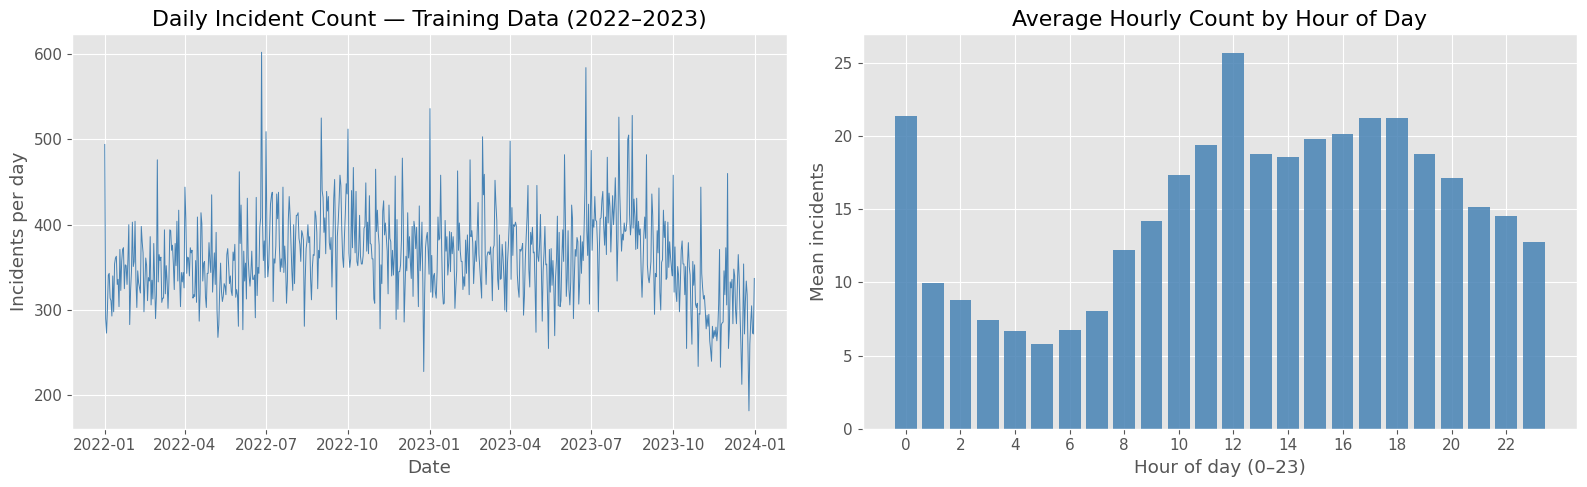

In [14]:
daily = train_sf.copy()
daily['date'] = daily['hour_bin'].dt.date
daily_sum = daily.groupby('date')['count'].sum()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].plot(pd.to_datetime(daily_sum.index), daily_sum.values, lw=0.7, color='steelblue')
axes[0].set_title('Daily Incident Count — Training Data (2022–2023)')
axes[0].set_xlabel('Date'); axes[0].set_ylabel('Incidents per day')

hmean = train_sf.groupby('hour_of_day')['count'].mean()
axes[1].bar(hmean.index, hmean.values, color='steelblue', alpha=0.85)
axes[1].set_title('Average Hourly Count by Hour of Day')
axes[1].set_xlabel('Hour of day (0–23)'); axes[1].set_ylabel('Mean incidents')
axes[1].set_xticks(range(0, 24, 2))
plt.tight_layout(); plt.show()

## 3. Shared Helpers

In [15]:
# ── PGM drawing ────────────────────────────────────────────────────────────────
def draw_pgm(fig_ax, nodes, edges, plates=None):
    r = 0.4
    for name, p in nodes.items():
        fc = '#dddddd' if p.get('obs') else 'white'
        fig_ax.add_patch(plt.Circle((p['x'], p['y']), r, fc=fc, ec='black', lw=2, zorder=3))
        fig_ax.text(p['x'], p['y'], p.get('label', name),
                    ha='center', va='center', fontsize=11, fontweight='bold', zorder=4)
    for (a, b) in edges:
        na, nb = nodes[a], nodes[b]
        dx, dy = nb['x']-na['x'], nb['y']-na['y']
        d = (dx**2+dy**2)**0.5
        fig_ax.annotate('',
                    xy=(nb['x']-r*dx/d, nb['y']-r*dy/d),
                    xytext=(na['x']+r*dx/d, na['y']+r*dy/d),
                    arrowprops=dict(arrowstyle='->', color='black', lw=1.5), zorder=2)
    if plates:
        for pl in plates:
            fig_ax.add_patch(plt.Rectangle((pl['x'],pl['y']),pl['w'],pl['h'],
                                        fill=False, ec='gray', lw=1.5, ls='--', zorder=1))
            fig_ax.text(pl['x']+pl['w']-0.1, pl['y']+0.15, pl.get('label',''),
                        ha='right', va='bottom', fontsize=9, color='gray')
    fig_ax.set_xlim(0,10); fig_ax.set_ylim(0,8)
    fig_ax.set_aspect('equal'); fig_ax.axis('off')

# ── SVI runner ──────────────────────────────────────────────────────────────────
def run_svi(model, args, n_steps=2000, lr=0.01, seed=42):
    pyro.set_rng_seed(seed)
    guide  = AutoDiagonalNormal(model)
    guide._pyro_name = "guide_" + model.__name__  # unique param store key per model
    svi    = SVI(model, guide, ClippedAdam({'lr': lr}), loss=Trace_ELBO())
    losses = []
    for step in range(n_steps):
        loss = svi.step(*args)
        losses.append(loss)
        if step % 500 == 0:
            print(f"  step {step:4d}   ELBO = {-loss:,.0f}")
    return guide, losses

# ── Metrics ─────────────────────────────────────────────────────────────────────
def metrics(y_true, y_pred):
    mae  = float(np.mean(np.abs(y_true - y_pred)))
    rmse = float(np.sqrt(np.mean((y_true - y_pred)**2)))
    return mae, rmse

print("Helpers ready.")

Helpers ready.


## 4. Model 1 — Homogeneous Poisson Process (Baseline)

The simplest possible model: crime arrives at a **constant rate** $\lambda$ everywhere, all the time.

### Generative Process

$$\lambda \sim \text{Gamma}(2.0,\; 0.1) \qquad \text{(mean = 20 incidents/hour)}$$
$$y_t \mid \lambda \sim \text{Poisson}(\lambda) \qquad t = 1,\ldots,T$$

The Gamma prior is conjugate to the Poisson likelihood. This model cannot capture any temporal or spatial variation — any model that beats it is learning real structure in the data.

Predicting the number of crime incidents per hour for any given hour in San Fransisco

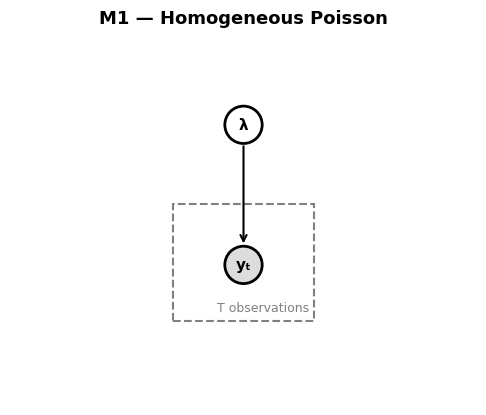

In [16]:
fig, fig_ax = plt.subplots(figsize=(5, 5))
draw_pgm(fig_ax,
    nodes={'lam': {'x':5,'y':6, 'label':'λ',  'obs':False},
           'y':   {'x':5,'y':3, 'label':'yₜ', 'obs':True}},
    edges=[('lam','y')],
    plates=[{'x':3.5,'y':1.8,'w':3,'h':2.5,'label':'T observations'}])
fig_ax.set_title('M1 — Homogeneous Poisson', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

In [17]:
def model_1(counts=None, N=None):
    lam = pyro.sample("lambda", dist.Gamma(torch.tensor(2.0), torch.tensor(0.1)))
    N_obs = len(counts) if counts is not None else N
    with pyro.plate("data", N_obs):
        pyro.sample("y", dist.Poisson(lam), obs=counts)

print("Model 1 defined.")

Model 1 defined.


In [18]:
pyro.clear_param_store()  # clear once before all model training
print("Training M1...")
guide_1, losses_1 = run_svi(model_1, (counts_tr_sf,), n_steps=2000, lr=0.01)

Training M1...
  step    0   ELBO = -97,237
  step  500   ELBO = -77,465
  step 1000   ELBO = -77,465
  step 1500   ELBO = -77,465


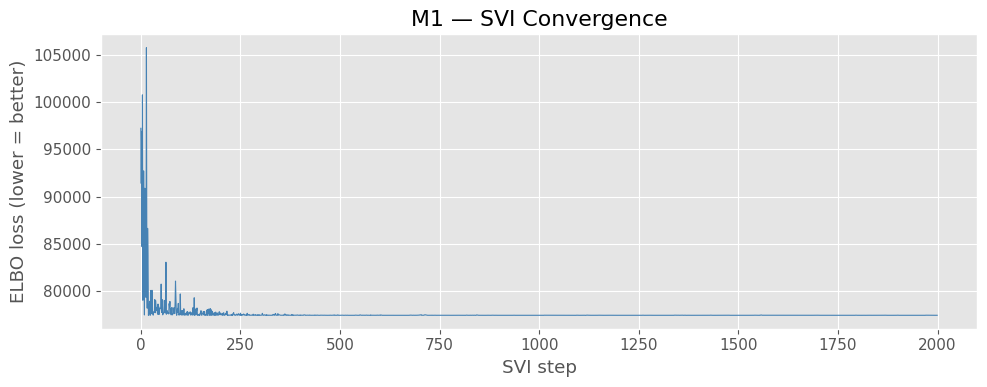

In [19]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(losses_1, lw=0.8, color='steelblue')
ax.set_xlabel('SVI step'); ax.set_ylabel('ELBO loss (lower = better)')
ax.set_title('M1 — SVI Convergence')
plt.tight_layout(); plt.show()

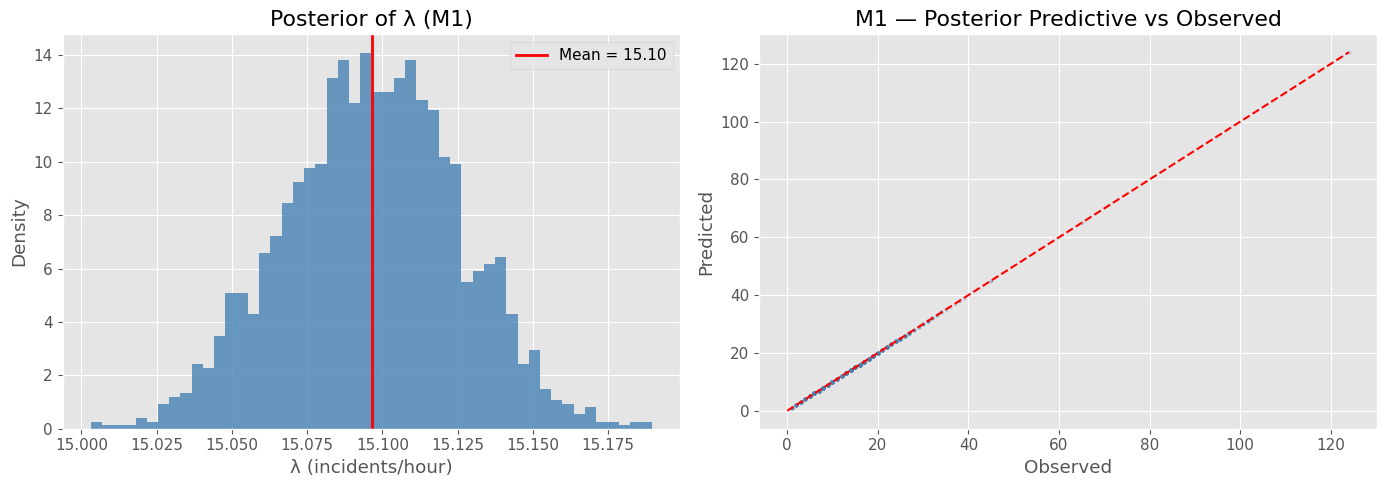

M1 Test → MAE: 6.021   RMSE: 7.428


In [20]:
samp_1 = Predictive(model_1, guide=guide_1, num_samples=2000,
                   return_sites=['lambda'])(counts_tr_sf)
lam_vi = samp_1['lambda'].squeeze().detach().numpy()

# Posterior predictive on train (sample y, not just lambda)
y_pp_1 = Predictive(model_1, guide=guide_1, num_samples=300,
                    return_sites=['y'])(counts_tr_sf)['y'].float().mean(0).detach().numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(lam_vi, bins=50, color='steelblue', alpha=0.8, density=True)
axes[0].axvline(lam_vi.mean(), color='red', lw=2, label=f'Mean = {lam_vi.mean():.2f}')
axes[0].set_xlabel('λ (incidents/hour)'); axes[0].set_ylabel('Density')
axes[0].set_title('Posterior of λ (M1)'); axes[0].legend()

axes[1].scatter(counts_tr_sf.numpy()[:1000], y_pp_1[:1000], alpha=0.2, s=5, color='steelblue')
lim = max(counts_tr_sf.max().item(), y_pp_1.max())
axes[1].plot([0,lim],[0,lim],'r--',lw=1.5)
axes[1].set_xlabel('Observed'); axes[1].set_ylabel('Predicted')
axes[1].set_title('M1 — Posterior Predictive vs Observed')
plt.tight_layout(); plt.show()

y_pred_te_1 = Predictive(model_1, guide=guide_1, num_samples=200,
                         return_sites=['y'])(N=len(counts_te_sf))['y'].float().mean(0).detach().numpy()
mae1, rmse1 = metrics(counts_te_sf.numpy(), y_pred_te_1)
print(f"M1 Test → MAE: {mae1:.3f}   RMSE: {rmse1:.3f}")

## 5. Model 2 — Inhomogeneous Poisson Process (Time of Day)

We let $\lambda(t)$ vary by **hour of day** and **day of week** using a log-linear intensity. This is the "time-of-day or not" comparison model.

### Generative Process

$$\alpha \sim \mathcal{N}(0,2)$$
$$\beta^{\text{hour}}_h \sim \mathcal{N}(0,1), \quad h=0,\ldots,23$$
$$\beta^{\text{dow}}_d \sim \mathcal{N}(0,1), \quad d=0,\ldots,6$$
$$\log\lambda_t = \alpha + \beta^{\text{hour}}_{h(t)} + \beta^{\text{dow}}_{d(t)}$$
$$y_t \mid \lambda_t \sim \text{Poisson}(\exp(\log\lambda_t))$$

The log link ensures $\lambda_t > 0$. Each hour-of-day gets its own coefficient so the model can learn any intra-day shape without assuming periodicity.

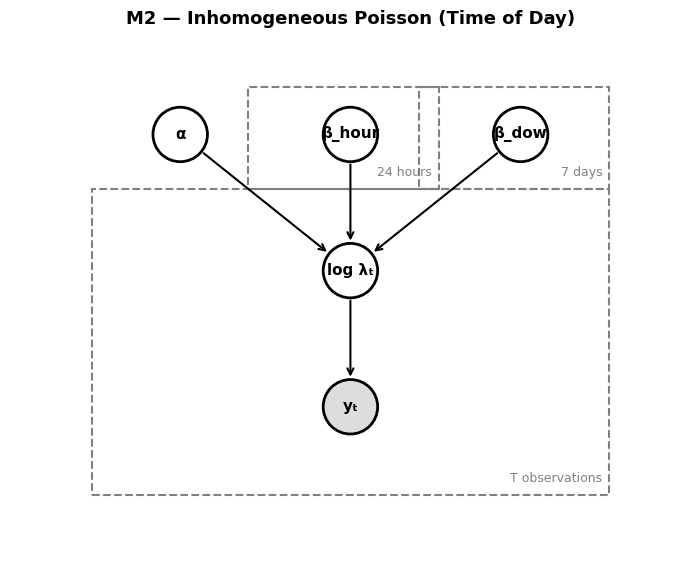

In [21]:
fig, fig_ax = plt.subplots(figsize=(9, 6))
draw_pgm(fig_ax,
    nodes={'alpha':   {'x':2.5,'y':6.5, 'label':'α',        'obs':False},
           'b_hour':  {'x':5.0,'y':6.5, 'label':'β_hour',   'obs':False},
           'b_dow':   {'x':7.5,'y':6.5, 'label':'β_dow',    'obs':False},
           'log_lam': {'x':5.0,'y':4.5, 'label':'log λₜ',   'obs':False},
           'y':       {'x':5.0,'y':2.5, 'label':'yₜ',       'obs':True}},
    edges=[('alpha','log_lam'),('b_hour','log_lam'),('b_dow','log_lam'),('log_lam','y')],
    plates=[{'x':1.2,'y':1.2,'w':7.6,'h':4.5,'label':'T observations'},
            {'x':3.5,'y':5.7,'w':2.8,'h':1.5,'label':'24 hours'},
            {'x':6.0,'y':5.7,'w':2.8,'h':1.5,'label':'7 days'}])
fig_ax.set_title('M2 — Inhomogeneous Poisson (Time of Day)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

In [22]:
def model_2(hour_idx, dow_idx, counts=None):
    alpha  = pyro.sample("alpha",  dist.Normal(torch.tensor(0.), torch.tensor(2.)))
    b_hour = pyro.sample("b_hour", dist.Normal(torch.zeros(24), torch.ones(24)).to_event(1))
    b_dow  = pyro.sample("b_dow",  dist.Normal(torch.zeros(7),  torch.ones(7)).to_event(1))
    log_rate = alpha + b_hour[hour_idx] + b_dow[dow_idx]
    with pyro.plate("data", len(hour_idx)):
        pyro.sample("y", dist.Poisson(torch.exp(log_rate)), obs=counts)

print("Model 2 defined.")

Model 2 defined.


In [23]:
print("Training M2...")
guide_2, losses_2 = run_svi(model_2, (hour_tr_sf, dow_tr_sf, counts_tr_sf), n_steps=2000, lr=0.01)

Training M2...
  step    0   ELBO = -517,257
  step  500   ELBO = -57,669
  step 1000   ELBO = -57,600
  step 1500   ELBO = -57,599


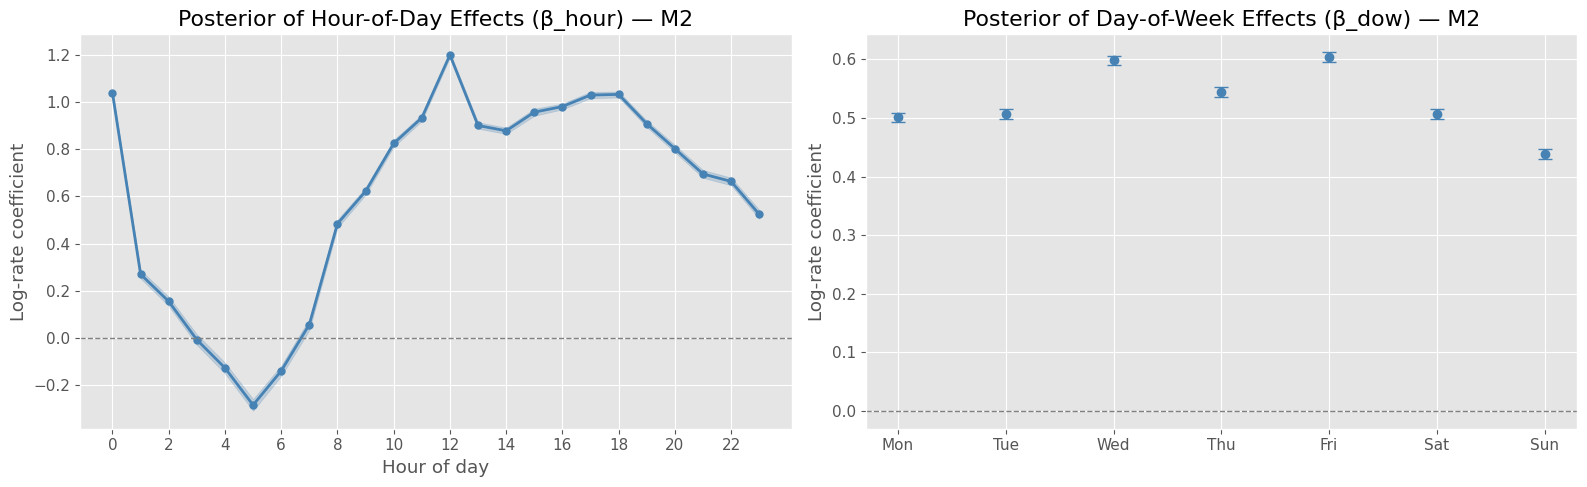

M2 Test → MAE: 4.743   RMSE: 6.025


In [24]:
samp_2 = Predictive(model_2, guide=guide_2, num_samples=2000,
                   return_sites=['b_hour','b_dow'])(hour_tr_sf, dow_tr_sf, counts_tr_sf)

bh = samp_2['b_hour'].squeeze()
bd = samp_2['b_dow'].squeeze()
bh_mean = bh.mean(0).detach().numpy()
bh_lo   = bh.quantile(0.05, dim=0).detach().numpy()
bh_hi   = bh.quantile(0.95, dim=0).detach().numpy()
bd_mean = bd.mean(0).detach().numpy()
bd_lo   = bd.quantile(0.05, dim=0).detach().numpy()
bd_hi   = bd.quantile(0.95, dim=0).detach().numpy()
DOW = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].plot(range(24), bh_mean, 'o-', color='steelblue', lw=2, ms=5)
axes[0].fill_between(range(24), bh_lo, bh_hi, alpha=0.25, color='steelblue')
axes[0].axhline(0, color='gray', ls='--', lw=1)
axes[0].set_xticks(range(0,24,2)); axes[0].set_xlabel('Hour of day')
axes[0].set_ylabel('Log-rate coefficient')
axes[0].set_title('Posterior of Hour-of-Day Effects (β_hour) — M2')

axes[1].errorbar(DOW, bd_mean, yerr=[bd_mean-bd_lo, bd_hi-bd_mean],
                 fmt='o', capsize=5, color='steelblue', lw=2)
axes[1].axhline(0, color='gray', ls='--', lw=1)
axes[1].set_ylabel('Log-rate coefficient')
axes[1].set_title('Posterior of Day-of-Week Effects (β_dow) — M2')
plt.tight_layout(); plt.show()

y_pred_te_2 = Predictive(model_2, guide=guide_2, num_samples=200,
    return_sites=['y'])(hour_te_sf, dow_te_sf)['y'].float().mean(0).detach().numpy()
mae2, rmse2 = metrics(counts_te_sf.numpy(), y_pred_te_2)
print(f"M2 Test → MAE: {mae2:.3f}   RMSE: {rmse2:.3f}")

## 6. Model 3 — Inhomogeneous Poisson Process (Districts)

We extend M2 by adding an independent **district effect** $\beta^{\text{dist}}_\ell$ for each of the $L$ police districts.

### Generative Process

$$\beta^{\text{dist}}_\ell \sim \mathcal{N}(0,1), \quad \ell = 1,\ldots,L$$
$$\log\lambda_{t\ell} = \alpha + \beta^{\text{hour}}_{h(t)} + \beta^{\text{dow}}_{d(t)} + \beta^{\text{dist}}_\ell$$
$$y_{t\ell} \sim \text{Poisson}(\exp(\log\lambda_{t\ell}))$$

Each district gets an independent $\mathcal{N}(0,1)$ prior — **no pooling** across districts. Model 4 relaxes this.

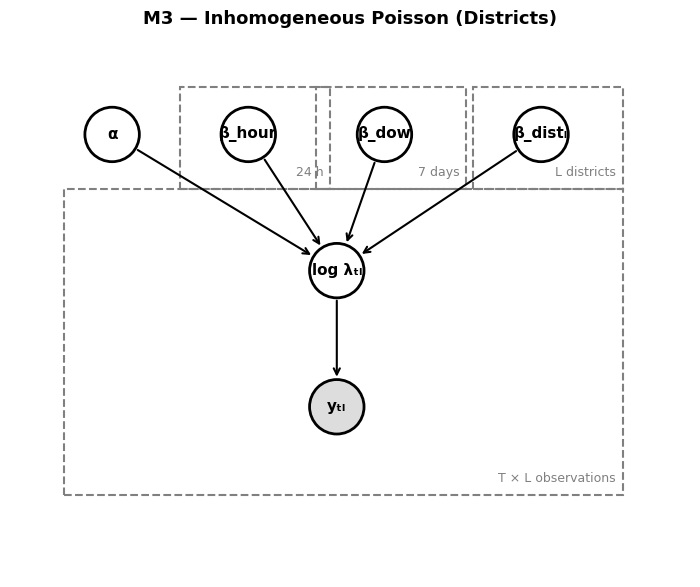

In [25]:
fig, fig_ax = plt.subplots(figsize=(10, 6))
draw_pgm(fig_ax,
    nodes={'alpha':   {'x':1.5,'y':6.5,'label':'α',        'obs':False},
           'b_hour':  {'x':3.5,'y':6.5,'label':'β_hour',   'obs':False},
           'b_dow':   {'x':5.5,'y':6.5,'label':'β_dow',    'obs':False},
           'b_dist':  {'x':7.8,'y':6.5,'label':'β_distₗ', 'obs':False},
           'log_lam': {'x':4.8,'y':4.5,'label':'log λₜₗ', 'obs':False},
           'y':       {'x':4.8,'y':2.5,'label':'yₜₗ',     'obs':True}},
    edges=[('alpha','log_lam'),('b_hour','log_lam'),('b_dow','log_lam'),
           ('b_dist','log_lam'),('log_lam','y')],
    plates=[{'x':0.8,'y':1.2,'w':8.2,'h':4.5,'label':'T × L observations'},
            {'x':2.5,'y':5.7,'w':2.2,'h':1.5,'label':'24 h'},
            {'x':4.5,'y':5.7,'w':2.2,'h':1.5,'label':'7 days'},
            {'x':6.8,'y':5.7,'w':2.2,'h':1.5,'label':'L districts'}])
fig_ax.set_title('M3 — Inhomogeneous Poisson (Districts)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

In [26]:
def model_3(hour_idx, dow_idx, dist_idx, N_D, counts=None):
    N_D = int(N_D)
    alpha  = pyro.sample("alpha",  dist.Normal(torch.tensor(0.), torch.tensor(2.)))
    b_hour = pyro.sample("b_hour", dist.Normal(torch.zeros(24), torch.ones(24)).to_event(1))
    b_dow  = pyro.sample("b_dow",  dist.Normal(torch.zeros(7),  torch.ones(7)).to_event(1))
    b_dist = pyro.sample("b_dist", dist.Normal(torch.zeros(N_D), torch.ones(N_D)).to_event(1))
    log_rate = alpha + b_hour[hour_idx] + b_dow[dow_idx] + b_dist[dist_idx]
    with pyro.plate("data", len(hour_idx)):
        pyro.sample("y", dist.Poisson(torch.exp(log_rate)), obs=counts)

print("Model 3 defined.")

Model 3 defined.


In [27]:
print("Training M3 — larger dataset (~193k obs), may take a few minutes...")
guide_3, losses_3 = run_svi(
    model_3,
    (hour_tr_d, dow_tr_d, distid_tr_d, N_DISTRICTS, counts_tr_d),
    n_steps=2000, lr=0.01)

Training M3 — larger dataset (~193k obs), may take a few minutes...
  step    0   ELBO = -369,158
  step  500   ELBO = -303,900
  step 1000   ELBO = -303,807
  step 1500   ELBO = -303,782


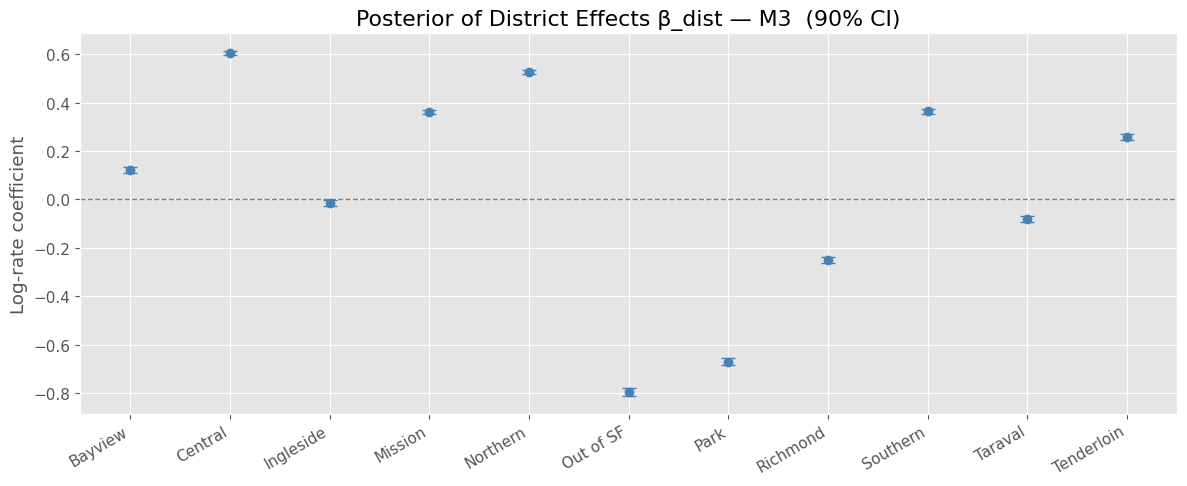

M3 Test → MAE: 1.098   RMSE: 1.480


In [28]:
samp_3 = Predictive(model_3, guide=guide_3, num_samples=1000,
                   return_sites=['b_dist'])(
    hour_tr_d, dow_tr_d, distid_tr_d, N_DISTRICTS, counts_tr_d)

bd3 = samp_3['b_dist'].squeeze()
bd3_mean = bd3.mean(0).detach().numpy()
bd3_lo   = bd3.quantile(0.05, dim=0).detach().numpy()
bd3_hi   = bd3.quantile(0.95, dim=0).detach().numpy()

fig, ax = plt.subplots(figsize=(12, 5))
ax.errorbar(range(N_DISTRICTS), bd3_mean,
            yerr=[bd3_mean-bd3_lo, bd3_hi-bd3_mean],
            fmt='o', capsize=5, color='steelblue', lw=2)
ax.axhline(0, color='gray', ls='--', lw=1)
ax.set_xticks(range(N_DISTRICTS)); ax.set_xticklabels(districts, rotation=30, ha='right')
ax.set_ylabel('Log-rate coefficient')
ax.set_title('Posterior of District Effects β_dist — M3  (90% CI)')
plt.tight_layout(); plt.show()

y_pred_te_3 = Predictive(model_3, guide=guide_3, num_samples=100,
    return_sites=['y'])(
    hour_te_d, dow_te_d, distid_te_d, N_DISTRICTS
)['y'].float().mean(0).detach().numpy()
mae3, rmse3 = metrics(counts_te_d.numpy(), y_pred_te_3)
print(f"M3 Test → MAE: {mae3:.3f}   RMSE: {rmse3:.3f}")

## 7. Model 4 — Hierarchical Poisson Process (Partial Pooling)

District effects now share a **common prior** with learned mean and variance. This is the key difference from M3: instead of independent $\mathcal{N}(0,1)$ priors, districts are drawn from a group distribution that is itself inferred from data.

### Generative Process

$$\mu_{\text{dist}} \sim \mathcal{N}(0,1), \quad \sigma_{\text{dist}} \sim \text{HalfNormal}(1)$$
$$\beta^{\text{dist}}_\ell \sim \mathcal{N}(\mu_{\text{dist}},\; \sigma_{\text{dist}}), \quad \ell = 1,\ldots,L$$
$$\log\lambda_{t\ell} = \alpha + \beta^{\text{hour}}_{h(t)} + \beta^{\text{dow}}_{d(t)} + \beta^{\text{dist}}_\ell$$
$$y_{t\ell} \sim \text{Poisson}(\exp(\log\lambda_{t\ell}))$$

**Partial pooling** shrinks district estimates toward the group mean, reducing posterior uncertainty — especially useful for low-activity districts with few observations.

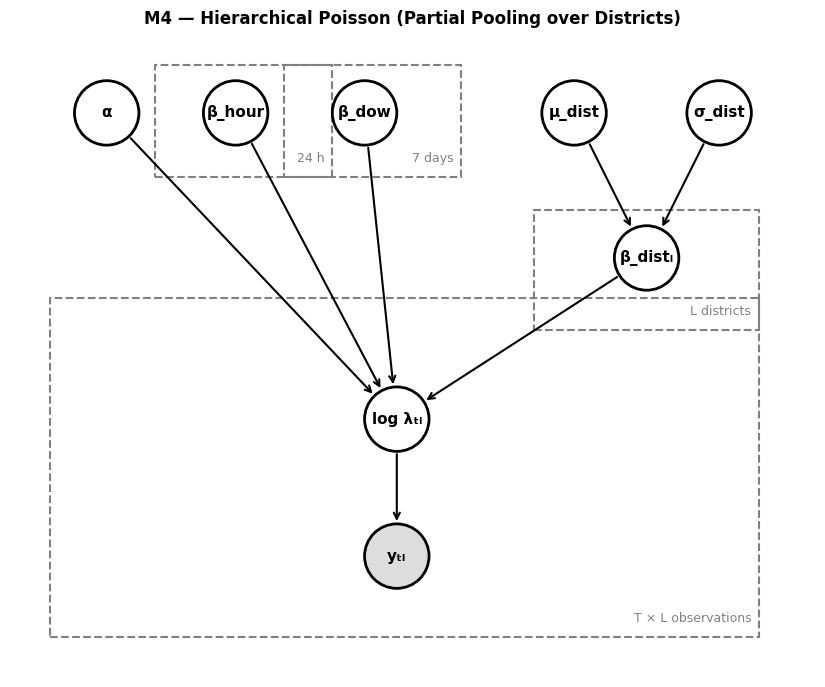

In [29]:
fig, fig_ax = plt.subplots(figsize=(10, 7))
draw_pgm(fig_ax,
    nodes={'alpha':   {'x':1.2,'y':7.0,'label':'α',         'obs':False},
           'b_hour':  {'x':2.8,'y':7.0,'label':'β_hour',    'obs':False},
           'b_dow':   {'x':4.4,'y':7.0,'label':'β_dow',     'obs':False},
           'mu_d':    {'x':7.0,'y':7.0,'label':'μ_dist',    'obs':False},
           'sig_d':   {'x':8.8,'y':7.0,'label':'σ_dist',    'obs':False},
           'b_dist':  {'x':7.9,'y':5.2,'label':'β_distₗ',  'obs':False},
           'log_lam': {'x':4.8,'y':3.2,'label':'log λₜₗ',  'obs':False},
           'y':       {'x':4.8,'y':1.5,'label':'yₜₗ',      'obs':True}},
    edges=[('alpha','log_lam'),('b_hour','log_lam'),('b_dow','log_lam'),
           ('mu_d','b_dist'),('sig_d','b_dist'),('b_dist','log_lam'),('log_lam','y')],
    plates=[{'x':0.5,'y':0.5,'w':8.8,'h':4.2,'label':'T × L observations'},
            {'x':6.5,'y':4.3,'w':2.8,'h':1.5,'label':'L districts'},
            {'x':1.8,'y':6.2,'w':2.2,'h':1.4,'label':'24 h'},
            {'x':3.4,'y':6.2,'w':2.2,'h':1.4,'label':'7 days'}])
fig_ax.set_title('M4 — Hierarchical Poisson (Partial Pooling over Districts)',
                 fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

In [30]:
def model_4(hour_idx, dow_idx, dist_idx, N_D, counts=None):
    N_D = int(N_D)
    alpha  = pyro.sample("alpha",  dist.Normal(torch.tensor(0.), torch.tensor(2.)))
    b_hour = pyro.sample("b_hour", dist.Normal(torch.zeros(24), torch.ones(24)).to_event(1))
    b_dow  = pyro.sample("b_dow",  dist.Normal(torch.zeros(7),  torch.ones(7)).to_event(1))
    mu_d   = pyro.sample("mu_dist",    dist.Normal(torch.tensor(0.), torch.tensor(1.)))
    sig_d  = pyro.sample("sigma_dist", dist.HalfNormal(torch.tensor(1.)))
    b_dist = pyro.sample("b_dist",
                         dist.Normal(torch.zeros(N_D) + mu_d, torch.zeros(N_D) + sig_d).to_event(1))
    log_rate = alpha + b_hour[hour_idx] + b_dow[dow_idx] + b_dist[dist_idx]
    with pyro.plate("data", len(hour_idx)):
        pyro.sample("y", dist.Poisson(torch.exp(log_rate)), obs=counts)

print("Model 4 defined.")

Model 4 defined.


In [31]:
print("Training M4 — Hierarchical Poisson...")
guide_4, losses_4 = run_svi(
    model_4,
    (hour_tr_d, dow_tr_d, distid_tr_d, N_DISTRICTS, counts_tr_d),
    n_steps=2000, lr=0.01)

Training M4 — Hierarchical Poisson...
  step    0   ELBO = -398,450
  step  500   ELBO = -303,946
  step 1000   ELBO = -303,798
  step 1500   ELBO = -303,788


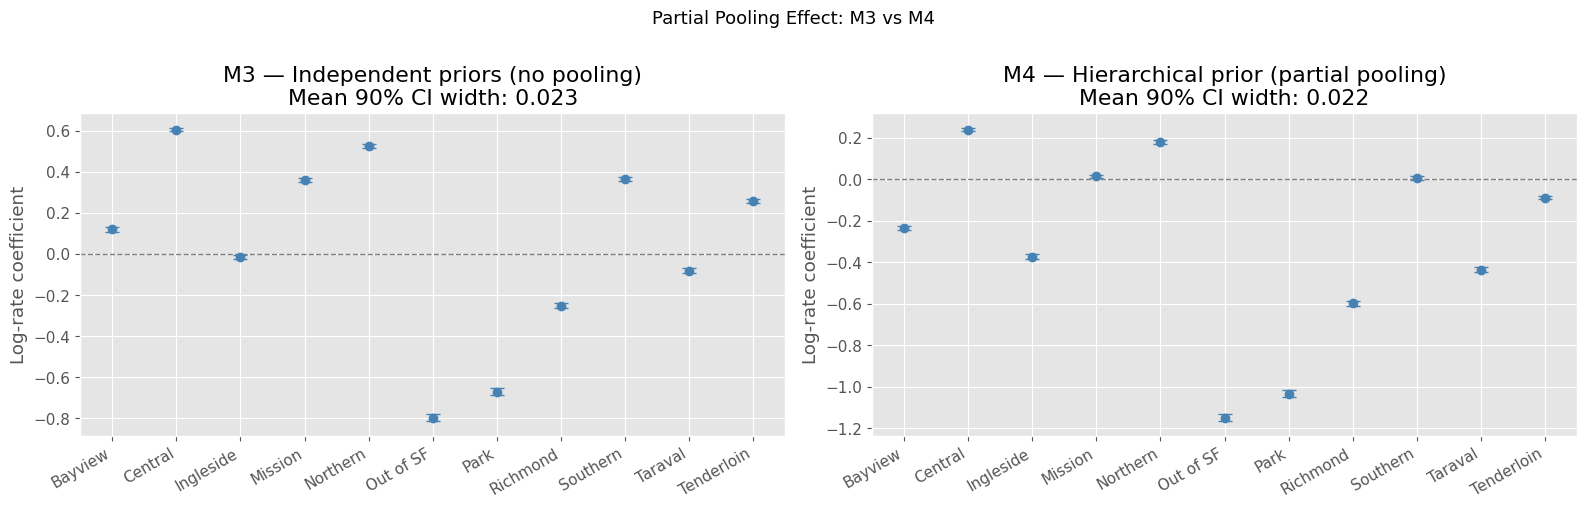

M4 Test → MAE: 1.102   RMSE: 1.481
σ_dist posterior mean: 0.525


In [32]:
samp_4 = Predictive(model_4, guide=guide_4, num_samples=1000,
                   return_sites=['b_dist','mu_dist','sigma_dist'])(
    hour_tr_d, dow_tr_d, distid_tr_d, N_DISTRICTS, counts_tr_d)

bd4 = samp_4['b_dist'].squeeze()
bd4_mean = bd4.mean(0).detach().numpy()
bd4_lo   = bd4.quantile(0.05, dim=0).detach().numpy()
bd4_hi   = bd4.quantile(0.95, dim=0).detach().numpy()

# M3 vs M4 partial pooling comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax_, mn, lo, hi, title in zip(
        axes,
        [bd3_mean, bd4_mean], [bd3_lo, bd4_lo], [bd3_hi, bd4_hi],
        ['M3 — Independent priors (no pooling)',
         'M4 — Hierarchical prior (partial pooling)']):
    ax_.errorbar(range(N_DISTRICTS), mn, yerr=[mn-lo, hi-mn],
                 fmt='o', capsize=5, color='steelblue', lw=2)
    ax_.axhline(0, color='gray', ls='--', lw=1)
    ax_.set_xticks(range(N_DISTRICTS))
    ax_.set_xticklabels(districts, rotation=30, ha='right')
    ax_.set_ylabel('Log-rate coefficient')
    ax_.set_title(f'{title}\nMean 90% CI width: {(hi-lo).mean():.3f}')
plt.suptitle('Partial Pooling Effect: M3 vs M4', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

y_pred_te_4 = Predictive(model_4, guide=guide_4, num_samples=100,
    return_sites=['y'])(
    hour_te_d, dow_te_d, distid_te_d, N_DISTRICTS
)['y'].float().mean(0).detach().numpy()
mae4, rmse4 = metrics(counts_te_d.numpy(), y_pred_te_4)
print(f"M4 Test → MAE: {mae4:.3f}   RMSE: {rmse4:.3f}")
print(f"σ_dist posterior mean: {samp_4['sigma_dist'].mean().item():.3f}")

## 8. Model Comparison

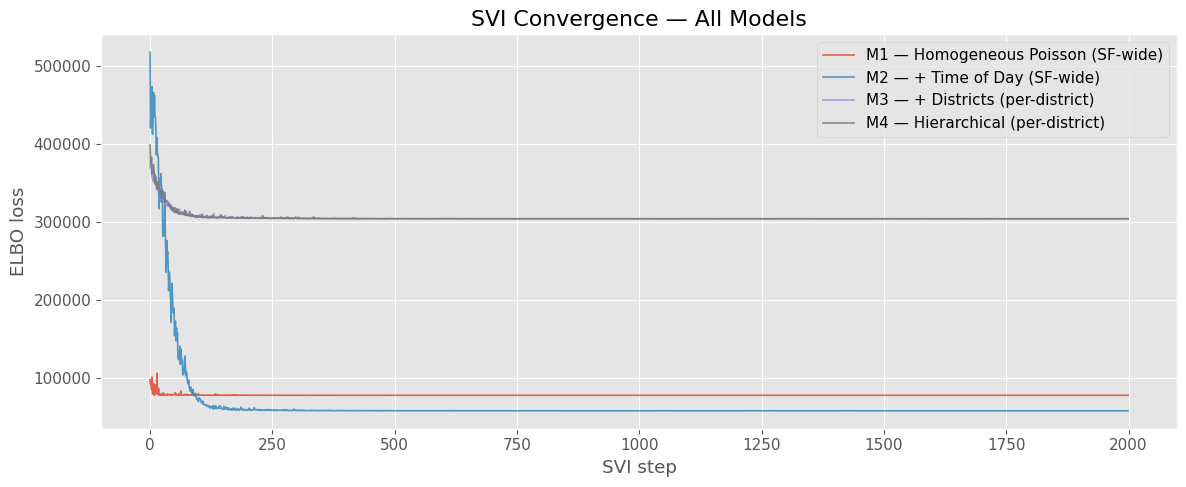

In [33]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(losses_1, lw=1.2, alpha=0.85, label='M1 — Homogeneous Poisson (SF-wide)')
ax.plot(losses_2, lw=1.2, alpha=0.85, label='M2 — + Time of Day (SF-wide)')
ax.plot(losses_3, lw=1.2, alpha=0.85, label='M3 — + Districts (per-district)')
ax.plot(losses_4, lw=1.2, alpha=0.85, label='M4 — Hierarchical (per-district)')
ax.set_xlabel('SVI step'); ax.set_ylabel('ELBO loss')
ax.set_title('SVI Convergence — All Models')
ax.legend(); plt.tight_layout(); plt.show()

           Model   MAE  RMSE
  M1 Homogeneous 6.021 7.428
M2 + Time of Day 4.743 6.025
  M3 + Districts 1.098 1.480
 M4 Hierarchical 1.102 1.481


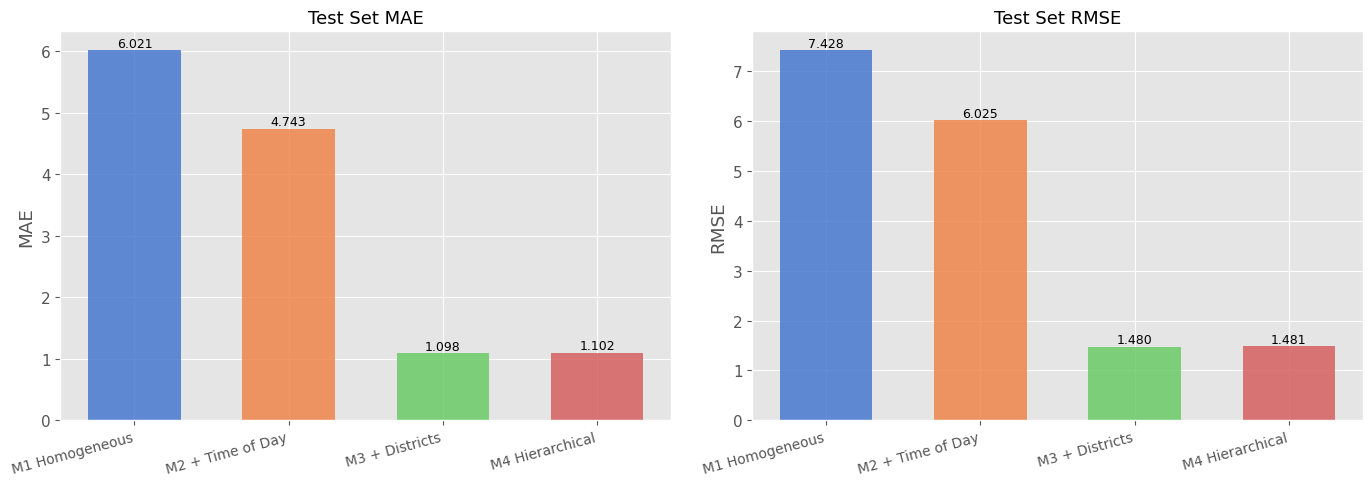

In [34]:
from IPython.display import display

results = pd.DataFrame({
    'Model':  ['M1 Homogeneous','M2 + Time of Day','M3 + Districts','M4 Hierarchical'],
    'MAE':    [round(mae1,3), round(mae2,3), round(mae3,3), round(mae4,3)],
    'RMSE':   [round(rmse1,3), round(rmse2,3), round(rmse3,3), round(rmse4,3)],
})
print(results.to_string(index=False))

x = np.arange(len(results))
colors = ['#4878d0','#ee854a','#6acc65','#d65f5f']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax_, metric in zip(axes, ['MAE','RMSE']):
    bars = ax_.bar(x, results[metric], color=colors, alpha=0.85, width=0.6)
    ax_.set_xticks(x)
    ax_.set_xticklabels(results['Model'], rotation=15, ha='right', fontsize=10)
    ax_.set_title(f'Test Set {metric}', fontsize=13)
    ax_.set_ylabel(metric)
    for bar, val in zip(bars, results[metric]):
        ax_.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
display(fig)
plt.close()


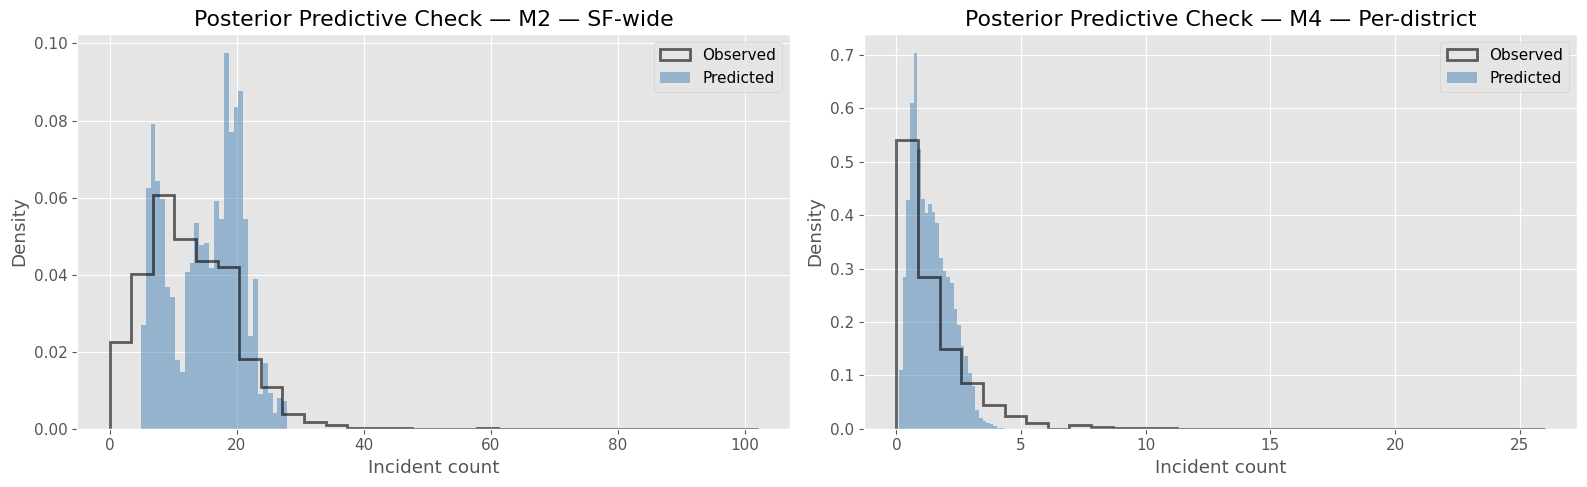

In [35]:
# Posterior predictive check: M2 (SF-wide) and M4 (per-district)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax_, guide_, model_, pred_args, y_true_tensor, title in [
    (axes[0], guide_2, model_2,
     (hour_te_sf, dow_te_sf),
     counts_te_sf, 'M2 — SF-wide'),
    (axes[1], guide_4, model_4,
     (hour_te_d, dow_te_d, distid_te_d, N_DISTRICTS),
     counts_te_d, 'M4 — Per-district'),
]:
    y_pp = Predictive(model_, guide=guide_, num_samples=200,
                      return_sites=['y'])(*pred_args)['y'].float().mean(0).detach().numpy()
    y_true = y_true_tensor.numpy()
    ax_.hist(y_true, bins=30, alpha=0.6, density=True,
             color='black', histtype='step', lw=2, label='Observed')
    ax_.hist(y_pp,   bins=30, alpha=0.5, density=True,
             color='steelblue', label='Predicted')
    ax_.set_xlabel('Incident count'); ax_.set_ylabel('Density')
    ax_.set_title(f'Posterior Predictive Check — {title}')
    ax_.legend()
plt.tight_layout()
display(fig)
plt.close()


## 9. VI vs MCMC (NUTS) on Model 1

As in the course exercises, we compare our variational approximation to NUTS on the simplest model. If the posteriors agree, VI is validated as a reliable approximation.

In [36]:
pyro.set_rng_seed(42)
nuts = NUTS(model_1, adapt_step_size=True)
mcmc = MCMC(nuts, num_samples=500, warmup_steps=200, disable_progbar=False)
mcmc.run(counts_tr_sf)
lam_mcmc = mcmc.get_samples()['lambda'].squeeze().detach().numpy()
print(f"MCMC done. Samples: {lam_mcmc.shape}")

Sample: 100%|██████████| 700/700 [00:02, 343.10it/s, step size=1.86e-01, acc. prob=0.930]

MCMC done. Samples: (500,)


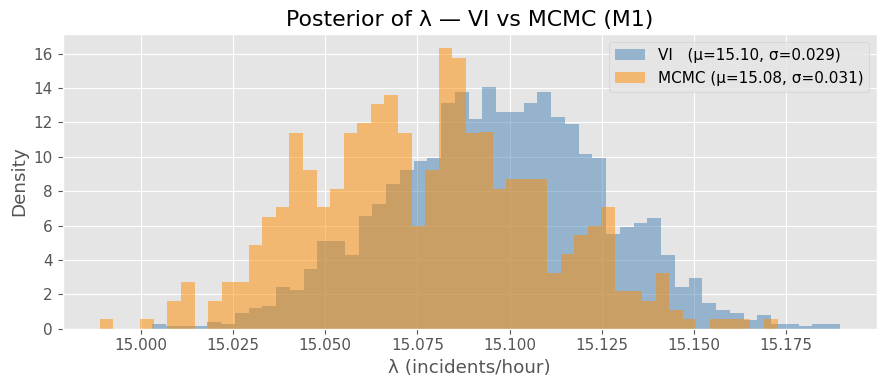

In [37]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(lam_vi,   bins=50, alpha=0.5, density=True, color='steelblue',
        label=f'VI   (μ={lam_vi.mean():.2f}, σ={lam_vi.std():.3f})')
ax.hist(lam_mcmc, bins=50, alpha=0.5, density=True, color='darkorange',
        label=f'MCMC (μ={lam_mcmc.mean():.2f}, σ={lam_mcmc.std():.3f})')
ax.set_xlabel('λ (incidents/hour)'); ax.set_ylabel('Density')
ax.set_title('Posterior of λ — VI vs MCMC (M1)')
ax.legend(); plt.tight_layout(); plt.show()

## 10. Discussion

### Summary

| Model | Key addition | Test data |
|---|---|---|
| M1 Homogeneous Poisson | Constant rate λ | SF-wide hourly |
| **M2 + Time of Day** | Hour + day-of-week effects | SF-wide hourly |
| M3 + Districts | Independent district effects | Per-district hourly |
| **M4 Hierarchical** | Partial pooling over districts | Per-district hourly |

### Key Findings

1. **Time of day matters (M1 → M2):** Hour-of-day posteriors show clear intra-day rhythm with afternoon/evening peaks. Adding these covariates substantially reduces test RMSE.

2. **Districts differ (M2 → M3):** District coefficients show large variation — Tenderloin, Mission, and Central are well above the citywide average.

3. **Partial pooling (M3 → M4):** The hierarchical prior narrows credible intervals, shrinking estimates toward the group mean. The inferred $\sigma_{\text{dist}}$ quantifies between-district heterogeneity.

4. **VI ≈ MCMC:** The `AutoDiagonalNormal` guide closely matches the NUTS posterior for M1, validating VI as a reliable and scalable approximation for all four models.

### Limitations & Extensions
- A **Hawkes process** could capture self-excitation (incidents triggering more incidents).
- A **GP prior** on $\lambda(t)$ would model smooth temporal trends without binning.
- Adding **crime category** as a covariate or as a separate model dimension.